# SynthACticBench with SMAC: minimum leaf sizes 1, 2, and 3

Three 500-trial runs on the same deterministic SynthACticBench objective. Only SMAC's `min_samples_leaf` changes.

In [1]:
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from carps.utils.running import make_problem
from carps.utils.trials import TrialInfo
from omegaconf import OmegaConf
from smac import AlgorithmConfigurationFacade as ACFacade
from smac import Scenario

PROBLEM_CONFIG = Path(
    "/home/io632776/experiments/adaptive-smac/external/SynthACticBench/"
    "synthacticbench/configs/problem/SynthACticBench/"
    "O1-DeterministicObjective.yaml"
)
N_TRIALS = 500
SMAC_SEED = 0
N_INSTANCES = 10
INSTANCE_SEED = 0

# Both SMAC runs use exactly these SynthACticBench instances.
rng = np.random.default_rng(INSTANCE_SEED)
instance_map = {
    f"i{i}": float(offset)
    for i, offset in enumerate(rng.normal(0, 2, N_INSTANCES))
}

In [2]:
def run_smac(min_samples_leaf):
    # A fresh copy gives both runs identical benchmark state.
    problem = make_problem(OmegaConf.load(PROBLEM_CONFIG))
    problem.set_instances(instance_map)

    def target_function(config, instance, seed=0):
        trial = TrialInfo(config=config, instance=instance, seed=seed)
        return float(problem.evaluate(trial).cost)

    scenario = Scenario(
        configspace=problem.configspace,
        deterministic=True,
        n_trials=N_TRIALS,
        seed=SMAC_SEED,
        instances=list(instance_map),
        output_directory=Path("smac_output") / f"min_leaf_{min_samples_leaf}",
    )
    model = ACFacade.get_model(
        scenario=scenario,
        min_samples_leaf=min_samples_leaf,
    )
    smac = ACFacade(
        scenario=scenario,
        target_function=target_function,
        model=model,
        overwrite=True,
    )
    incumbent = smac.optimize()

    # Count how many instance evaluations each configuration received.
    trials_per_config = Counter(key.config_id for key in smac.runhistory)
    config_trial_counts = pd.DataFrame(
        [
            {
                "config_id": config_id,
                "n_trials": n_config_trials,
                "configuration": dict(smac.runhistory.get_config(config_id)),
            }
            for config_id, n_config_trials in trials_per_config.items()
        ]
    ).sort_values(["n_trials", "config_id"], ascending=[False, True])

    # Remove the known instance offset for a comparable objective trace.
    ordered_trials = sorted(
        smac.runhistory.items(),
        key=lambda item: (item[1].starttime, item[1].endtime),
    )
    objective_values = [
        float(value.cost) - instance_map[key.instance]
        for key, value in ordered_trials
    ]
    best_so_far = np.minimum.accumulate(objective_values)

    return {
        "min_samples_leaf": min_samples_leaf,
        "n_trials": len(smac.runhistory),
        "incumbent_cost": float(smac.runhistory.get_cost(incumbent)),
        "incumbent": dict(incumbent),
        "config_trial_counts": config_trial_counts,
        "best_so_far": best_so_far,
    }

In [3]:
result_leaf_1 = run_smac(1)
{key: result_leaf_1[key] for key in ("min_samples_leaf", "n_trials", "incumbent_cost", "incumbent")}

Lower bound: -100, 10
[WARNING][abstract_encoder.py:74] We strongly encourage to use instance features when using instances.If no instance features are passed, the runhistory encoder can not distinguish between different instances and therefore returns the same data points with different values, all of which are used to train the surrogate model.
Consider using instance indices as features.
[INFO][abstract_initial_design.py:143] Using 1 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config 76d066 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config 84b2f1 and rejected config 76d066 as incumbent because it is not better than the incumbents on 2 instances: 
[INFO][abstract_intensifier.py:630] Added config 1dab76 and rejected config 84b2f1 as incumbent because it is not better than the incumbents on 

{'min_samples_leaf': 1,
 'n_trials': 500,
 'incumbent_cost': -300569.8140282029,
 'incumbent': {'x_0': -21.1344551914298,
  'x_1': -97.715510697604,
  'x_2': -94.5426190221075,
  'x_3': 11.7941542907092,
  'x_4': -90.7015092944037,
  'x_5': -99.8143924603442,
  'x_6': -7.9669698679135,
  'x_7': 7.1392808030796,
  'x_8': 89.563715300026,
  'x_9': -99.7461070475663}}

In [4]:
result_leaf_2 = run_smac(2)
{key: result_leaf_2[key] for key in ("min_samples_leaf", "n_trials", "incumbent_cost", "incumbent")}

Lower bound: -100, 10
[WARNING][abstract_encoder.py:74] We strongly encourage to use instance features when using instances.If no instance features are passed, the runhistory encoder can not distinguish between different instances and therefore returns the same data points with different values, all of which are used to train the surrogate model.
Consider using instance indices as features.
[INFO][abstract_initial_design.py:143] Using 1 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config 76d066 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config 84b2f1 and rejected config 76d066 as incumbent because it is not better than the incumbents on 2 instances: 
[INFO][abstract_intensifier.py:630] Added config 9fbb48 and rejected config 84b2f1 as incumbent because it is not better than the incumbents on 

{'min_samples_leaf': 2,
 'n_trials': 500,
 'incumbent_cost': -307812.1401446308,
 'incumbent': {'x_0': -24.7765066347368,
  'x_1': 98.816064390713,
  'x_2': -67.5618197568145,
  'x_3': 6.2619928079779,
  'x_4': 98.112939582375,
  'x_5': -98.756071375757,
  'x_6': 9.2692568052232,
  'x_7': 9.9982972022093,
  'x_8': 13.6892300014589,
  'x_9': -96.3900276374295}}

In [5]:
result_leaf_3 = run_smac(3)
{key: result_leaf_3[key] for key in ("min_samples_leaf", "n_trials", "incumbent_cost", "incumbent")}

Lower bound: -100, 10
[WARNING][abstract_encoder.py:74] We strongly encourage to use instance features when using instances.If no instance features are passed, the runhistory encoder can not distinguish between different instances and therefore returns the same data points with different values, all of which are used to train the surrogate model.
Consider using instance indices as features.
[INFO][abstract_initial_design.py:143] Using 1 initial design configurations and 0 additional configurations.
[INFO][abstract_intensifier.py:313] Using only one seed for deterministic scenario.
[INFO][abstract_intensifier.py:523] Added config 76d066 as new incumbent because there are no incumbents yet.
[INFO][abstract_intensifier.py:630] Added config 84b2f1 and rejected config 76d066 as incumbent because it is not better than the incumbents on 2 instances: 
[INFO][abstract_intensifier.py:630] Added config 79f3a1 and rejected config 84b2f1 as incumbent because it is not better than the incumbents on 

{'min_samples_leaf': 3,
 'n_trials': 500,
 'incumbent_cost': -280927.96880925505,
 'incumbent': {'x_0': 80.3095392386597,
  'x_1': -99.6043382628566,
  'x_2': -99.5936181113187,
  'x_3': 17.2023816988913,
  'x_4': -80.2072374052969,
  'x_5': 99.6654516676789,
  'x_6': -9.2200270000719,
  'x_7': -16.3587436316617,
  'x_8': -1.5381921355782,
  'x_9': 99.3803371969186}}

In [6]:
{
    "leaf_1_cost": result_leaf_1["incumbent_cost"],
    "leaf_2_cost": result_leaf_2["incumbent_cost"],
    "leaf_3_cost": result_leaf_3["incumbent_cost"],
}

{'leaf_1_cost': -300569.8140282029,
 'leaf_2_cost': -307812.1401446308,
 'leaf_3_cost': -280927.96880925505}

## Trials allocated to each configuration

In [7]:
print("min_samples_leaf = 1")
display(result_leaf_1["config_trial_counts"])

print("min_samples_leaf = 2")
display(result_leaf_2["config_trial_counts"])

print("min_samples_leaf = 3")
display(result_leaf_3["config_trial_counts"])

min_samples_leaf = 1


,config_id,n_trials,configuration
1,2,10,"{'x_0': -89.1228637062783, 'x_1': 60.185272767..."
22,23,10,"{'x_0': 8.2637745123162, 'x_1': -76.8785992578..."
33,34,10,"{'x_0': 45.1751615571446, 'x_1': 99.9225470429..."
34,35,10,"{'x_0': 2.2248277794561, 'x_1': -76.4384814317..."
36,37,10,"{'x_0': -12.4866853877951, 'x_1': -85.49061155..."
...,...,...,...
322,323,1,"{'x_0': 41.2467435111539, 'x_1': -46.989757874..."
323,324,1,"{'x_0': -55.5577600333563, 'x_1': 36.665625827..."
324,325,1,"{'x_0': -39.8724989693467, 'x_1': 61.149305934..."
325,326,1,"{'x_0': 29.2647745466091, 'x_1': -48.955923741..."


min_samples_leaf = 2


,config_id,n_trials,configuration
1,2,10,"{'x_0': -89.1228637062783, 'x_1': 60.185272767..."
9,10,10,"{'x_0': -88.1668773009302, 'x_1': 75.748665344..."
18,19,10,"{'x_0': -19.6235015817922, 'x_1': 95.734666910..."
50,51,10,"{'x_0': 44.1384440699044, 'x_1': 89.9216732587..."
94,95,10,"{'x_0': 84.6482000035965, 'x_1': 99.9933089073..."
...,...,...,...
350,351,1,"{'x_0': -18.4158082492539, 'x_1': 98.801525448..."
351,352,1,"{'x_0': -27.469726238181, 'x_1': 98.9405658872..."
352,353,1,"{'x_0': 65.2294015191962, 'x_1': 27.0765905750..."
353,354,1,"{'x_0': 54.9972914558886, 'x_1': -18.386231040..."


min_samples_leaf = 3


,config_id,n_trials,configuration
1,2,10,"{'x_0': -89.1228637062783, 'x_1': 60.185272767..."
18,19,10,"{'x_0': -87.3698763959152, 'x_1': -89.05808492..."
26,27,10,"{'x_0': -87.0499613219875, 'x_1': -90.26516193..."
37,38,10,"{'x_0': -86.2718651299317, 'x_1': -97.87821299..."
50,51,10,"{'x_0': 44.1384440699044, 'x_1': 89.9216732587..."
...,...,...,...
341,342,1,"{'x_0': -38.129752551319, 'x_1': -39.960812498..."
342,343,1,"{'x_0': 80.4177229515702, 'x_1': -24.840770390..."
343,344,1,"{'x_0': -66.9567074813287, 'x_1': 83.335825803..."
344,345,1,"{'x_0': -29.7880428913714, 'x_1': -7.439830063..."


## Visualization

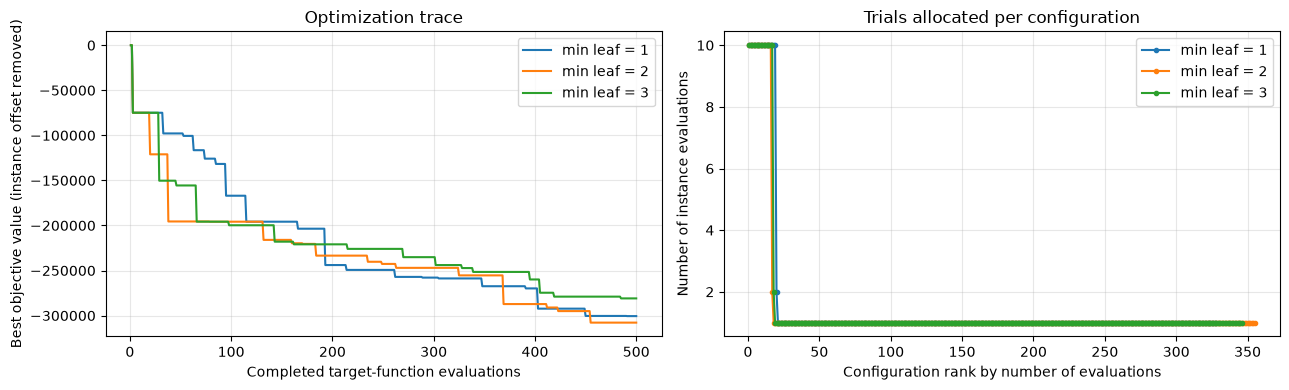

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for result, label in [
    (result_leaf_1, "min leaf = 1"),
    (result_leaf_2, "min leaf = 2"),
    (result_leaf_3, "min leaf = 3"),
]:
    axes[0].plot(
        range(1, len(result["best_so_far"]) + 1),
        result["best_so_far"],
        label=label,
    )
    counts = result["config_trial_counts"]["n_trials"].sort_values(ascending=False)
    axes[1].plot(range(1, len(counts) + 1), counts, marker=".", label=label)

axes[0].set(
    xlabel="Completed target-function evaluations",
    ylabel="Best objective value (instance offset removed)",
    title="Optimization trace",
)
axes[1].set(
    xlabel="Configuration rank by number of evaluations",
    ylabel="Number of instance evaluations",
    title="Trials allocated per configuration",
)
for axis in axes:
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()